# 1. ResNet-34 모델 구현 (1번 프로젝트)

## 1-1. Resnet 기본 블럭

In [45]:
!pip install -q torchinfo

import torch
import torch.nn as nn
from torchinfo import summary   # 중요: torchsummary가 아니라 torchinfo

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



# 1. BasicBlock: ResNet-18, 34

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels * self.expansion,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += self.shortcut(identity)
        out = self.relu(out)

        return out



## 1-2. ResNet-50 구조 구현을 위한 Bottleneck 구성 코드

In [46]:
# 2. Bottleneck: ResNet-50, 101, 152
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1, stride=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(
            out_channels, out_channels * self.expansion,
            kernel_size=1, stride=1, bias=False
        )
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels * self.expansion,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        out += self.shortcut(identity)
        out = self.relu(out)

        return out

## 1-3. ResNet의 main class

In [47]:
# 3. ResNet main class
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=1000):
        super().__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(
            3, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64,  num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []

        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)      # [B, 64, 112, 112]
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)    # [B, 64, 56, 56]

        x = self.layer1(x)     # stage 1
        x = self.layer2(x)     # stage 2
        x = self.layer3(x)     # stage 3
        x = self.layer4(x)     # stage 4

        x = self.avgpool(x)    # [B, C, 1, 1]
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x



## 1-4. build_resnet builder를 이용하여 34, 50 build 만들기

In [48]:
# 4. builder
def build_resnet(model_code, num_classes=1000):
    cfgs = {
        '34': (BasicBlock, [3, 4, 6, 3]),
        '50': (Bottleneck, [3, 4, 6, 3]),
    }

    if model_code not in cfgs:
        raise ValueError("Choose model_code from '34' or '50'.")

    block, layers = cfgs[model_code]
    return ResNet(block, layers, num_classes)

## 1-5. Test

In [52]:
resnet_34 = build_resnet('34').to(device)
resnet_50 = build_resnet('50').to(device)

summary(resnet_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─Sequential: 3-6              [1, 64, 56, 56]           --
│

In [53]:
summary(resnet_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 

# 2. Plain Network 만들기 (1번 프로젝트)

## 2-1 기본 블럭 만들기

In [54]:
import torch
import torch.nn as nn
from torchinfo import summary




class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # skip connection용 shortcut
        self.shortcut = nn.Sequential()
        if self.use_skip and (stride != 1 or in_channels != out_channels * self.expansion):
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels * self.expansion,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.use_skip:
            out += self.shortcut(identity)

        out = self.relu(out)
        return out



## 2-2. Bottleneck 만들기(PlaniNet_50)

In [55]:
# 2. Bottleneck 만들기

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1, stride=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(
            out_channels, out_channels * self.expansion,
            kernel_size=1, stride=1, bias=False
        )
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)

        # skip connection용 shortcut
        self.shortcut = nn.Sequential()
        if self.use_skip and (stride != 1 or in_channels != out_channels * self.expansion):
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels * self.expansion,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.use_skip:
            out += self.shortcut(identity)

        out = self.relu(out)
        return out



## 2-3. 공통 네트워크 클래스

In [56]:
class CNNNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=1000, use_skip=True):
        super().__init__()
        self.in_channels = 64
        self.use_skip = use_skip

        # 입력 이미지 크기: (224, 224, 3)
        # PyTorch 입력 텐서: (N, 3, 224, 224)
        self.conv1 = nn.Conv2d(
            3, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64,  num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []

        for s in strides:
            layers.append(
                block(
                    self.in_channels,
                    out_channels,
                    stride=s,
                    use_skip=self.use_skip
                )
            )
            self.in_channels = out_channels * block.expansion

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)      # [N, 64, 112, 112]
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)    # [N, 64, 56, 56]

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)    # [N, C, 1, 1]
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


## 2-4. PlainNet 생성 함수

In [57]:
def build_plainnet(model_code, num_classes=1000):
    cfgs = {
        '34': (BasicBlock, [3, 4, 6, 3]),
        '50': (Bottleneck, [3, 4, 6, 3]),
    }

    if model_code not in cfgs:
        raise ValueError("model_code must be '34' or '50'")

    block, layers = cfgs[model_code]
    return CNNNet(block, layers, num_classes=num_classes, use_skip=False) # skip을 False로 해놓아서 plain




## 2-5. ResNet 생성함수

In [58]:
def build_resnet(model_code, num_classes=1000):
    cfgs = {
        '34': (BasicBlock, [3, 4, 6, 3]),
        '50': (Bottleneck, [3, 4, 6, 3]),
    }

    if model_code not in cfgs:
        raise ValueError("model_code must be '34' or '50'")

    block, layers = cfgs[model_code]
    return CNNNet(block, layers, num_classes=num_classes, use_skip=True) # skip을 True로 해놓아서 residual

## 2-6. Test

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_34 = build_resnet('34').to(device)
resnet_50 = build_resnet('50').to(device)

plainnet_34 = build_plainnet('34').to(device)
plainnet_50 = build_plainnet('50').to(device)

print("\n=== PlainNet-34 ===")
summary(plainnet_34, input_size=(1, 3, 224, 224))


=== PlainNet-34 ===


Layer (type:depth-idx)                   Output Shape              Param #
CNNNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

In [61]:
print("\n=== ResNet-34 ===")
summary(resnet_34, input_size=(1, 3, 224, 224))


=== ResNet-34 ===


Layer (type:depth-idx)                   Output Shape              Param #
CNNNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─Sequential: 3-6              [1, 64, 56, 56]           --
│

# 3. ResNet vs PlainNet (2번, 3번 프로젝트)

## 3-1 Data Load

In [2]:
# Pytorch
import torch
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])
train_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

test_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="test",
    target_types="category",
    transform=transform,
    download=True
)

## 3-1 BasicBlock-build

In [3]:
!pip install torchinfo
import torch
import torch.nn as nn
from torchinfo import summary




class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # skip connection용 shortcut
        self.shortcut = nn.Sequential()
        if self.use_skip and (stride != 1 or in_channels != out_channels * self.expansion):
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels * self.expansion,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.use_skip:
            out += self.shortcut(identity)

        out = self.relu(out)
        return out
# 2. Bottleneck 만들기

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1, stride=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(
            out_channels, out_channels * self.expansion,
            kernel_size=1, stride=1, bias=False
        )
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)

        # skip connection용 shortcut
        self.shortcut = nn.Sequential()
        if self.use_skip and (stride != 1 or in_channels != out_channels * self.expansion):
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels * self.expansion,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.use_skip:
            out += self.shortcut(identity)

        out = self.relu(out)
        return out
#공통네트워크
class CNNNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=1000, use_skip=True):
        super().__init__()
        self.in_channels = 64
        self.use_skip = use_skip

        # 입력 이미지 크기: (224, 224, 3)
        # PyTorch 입력 텐서: (N, 3, 224, 224)
        self.conv1 = nn.Conv2d(
            3, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64,  num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []

        for s in strides:
            layers.append(
                block(
                    self.in_channels,
                    out_channels,
                    stride=s,
                    use_skip=self.use_skip
                )
            )
            self.in_channels = out_channels * block.expansion

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)      # [N, 64, 112, 112]
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)    # [N, 64, 56, 56]

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)    # [N, C, 1, 1]
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

# plainnet build
def build_plainnet(model_code, num_classes=1000):
    cfgs = {
        '34': (BasicBlock, [3, 4, 6, 3]),
        '50': (Bottleneck, [3, 4, 6, 3]),
    }

    if model_code not in cfgs:
        raise ValueError("model_code must be '34' or '50'")

    block, layers = cfgs[model_code]
    return CNNNet(block, layers, num_classes=num_classes, use_skip=False) # skip을 False로 해놓아서 plain

# resnet build
def build_resnet(model_code, num_classes=1000):
    cfgs = {
        '34': (BasicBlock, [3, 4, 6, 3]),
        '50': (Bottleneck, [3, 4, 6, 3]),
    }

    if model_code not in cfgs:
        raise ValueError("model_code must be '34' or '50'")

    block, layers = cfgs[model_code]
    return CNNNet(block, layers, num_classes=num_classes, use_skip=True) # skip을 True로 해놓아서 residual




## 3-2 ResNet_34 training

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model
num_classes = len(train_dataset.classes)
model = build_resnet('34', num_classes=num_classes).to(device)


# Loss / Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

# Train
num_epochs = 15

resnet34_train_losses = []
resnet34_val_accuracy = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_loss / train_total
    train_acc = train_correct / train_total
    resnet34_train_losses.append(train_loss)

    model.eval()
    test_loss_sum = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss_sum += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    test_loss = test_loss_sum / test_total
    test_acc = test_correct / test_total
    resnet34_val_accuracy.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch [1/15] Train Loss: 3.6540, Train Acc: 0.0503 | Test Loss: 3.5276, Test Acc: 0.0725
Epoch [2/15] Train Loss: 3.3455, Train Acc: 0.0967 | Test Loss: 3.3913, Test Acc: 0.0886
Epoch [3/15] Train Loss: 3.2050, Train Acc: 0.1193 | Test Loss: 3.7161, Test Acc: 0.0883
Epoch [4/15] Train Loss: 3.0585, Train Acc: 0.1508 | Test Loss: 3.4973, Test Acc: 0.1049
Epoch [5/15] Train Loss: 2.9458, Train Acc: 0.1636 | Test Loss: 3.4891, Test Acc: 0.1180
Epoch [6/15] Train Loss: 2.8307, Train Acc: 0.1989 | Test Loss: 3.1340, Test Acc: 0.1428
Epoch [7/15] Train Loss: 2.6946, Train Acc: 0.2304 | Test Loss: 3.1528, Test Acc: 0.1660
Epoch [8/15] Train Loss: 2.5967, Train Acc: 0.2554 | Test Loss: 2.8959, Test Acc: 0.2020
Epoch [9/15] Train Loss: 2.4727, Train Acc: 0.2832 | Test Loss: 2.9774, Test Acc: 0.1870
Epoch [10/15] Train Loss: 2.3033, Train Acc: 0.3261 | Test Loss: 3.0767, Test Acc: 0.1900
Epoch [11/15] Train Loss: 2.1699, Train Acc: 0.3614 | Test Loss: 3.5413, Test Acc: 0.1695
Epoch [12/15] Train

In [11]:
resnet34_model = model
torch.save(resnet34_model.state_dict(),"resnet34.pth")

## ❌문제점 발생 후 조치❌ 
```
Epoch [1/30] Train Loss: 3.7226, Train Acc: 0.0484 | Test Loss: 3.5769, Test Acc: 0.0564
Epoch [2/30] Train Loss: 3.5140, Train Acc: 0.0614 | Test Loss: 3.4536, Test Acc: 0.0780
Epoch [3/30] Train Loss: 3.3799, Train Acc: 0.0840 | Test Loss: 3.4825, Test Acc: 0.0801
Epoch [4/30] Train Loss: 3.2499, Train Acc: 0.1068 | Test Loss: 3.2532, Test Acc: 0.1098
Epoch [5/30] Train Loss: 3.1471, Train Acc: 0.1261 | Test Loss: 3.2830, Test Acc: 0.1158
Epoch [6/30] Train Loss: 3.0597, Train Acc: 0.1457 | Test Loss: 3.7596, Test Acc: 0.0733
Epoch [7/30] Train Loss: 2.9498, Train Acc: 0.1720 | Test Loss: 3.3658, Test Acc: 0.1169
Epoch [8/30] Train Loss: 2.8712, Train Acc: 0.1875 | Test Loss: 3.0693, Test Acc: 0.1842
Epoch [9/30] Train Loss: 2.7671, Train Acc: 0.2117 | Test Loss: 3.1959, Test Acc: 0.1423
Epoch [10/30] Train Loss: 2.6804, Train Acc: 0.2402 | Test Loss: 3.2450, Test Acc: 0.1584
Epoch [11/30] Train Loss: 2.5664, Train Acc: 0.2625 | Test Loss: 3.2316, Test Acc: 0.1605
Epoch [12/30] Train Loss: 2.4688, Train Acc: 0.2875 | Test Loss: 3.0610, Test Acc: 0.1883
Epoch [13/30] Train Loss: 2.3415, Train Acc: 0.3103 | Test Loss: 3.4873, Test Acc: 0.1420
Epoch [14/30] Train Loss: 2.2058, Train Acc: 0.3495 | Test Loss: 2.7545, Test Acc: 0.2388
Epoch [15/30] Train Loss: 2.0218, Train Acc: 0.4057 | Test Loss: 3.6846, Test Acc: 0.1753
Epoch [16/30] Train Loss: 1.8868, Train Acc: 0.4291 | Test Loss: 3.0934, Test Acc: 0.2202
Epoch [17/30] Train Loss: 1.6730, Train Acc: 0.4799 | Test Loss: 3.4446, Test Acc: 0.2197
Epoch [18/30] Train Loss: 1.4442, Train Acc: 0.5571 | Test Loss: 3.5400, Test Acc: 0.2159
Epoch [19/30] Train Loss: 1.2418, Train Acc: 0.6098 | Test Loss: 3.4788, Test Acc: 0.2221
Epoch [20/30] Train Loss: 0.9993, Train Acc: 0.6807 | Test Loss: 3.6473, Test Acc: 0.2434
Epoch [21/30] Train Loss: 0.8272, Train Acc: 0.7340 | Test Loss: 3.6783, Test Acc: 0.2535
Epoch [22/30] Train Loss: 0.5226, Train Acc: 0.8405 | Test Loss: 4.7544, Test Acc: 0.1829
Epoch [23/30] Train Loss: 0.4343, Train Acc: 0.8584 | Test Loss: 3.7855, Test Acc: 0.2625
Epoch [24/30] Train Loss: 0.2701, Train Acc: 0.9217 | Test Loss: 4.8012, Test Acc: 0.2197
Epoch [25/30] Train Loss: 0.1767, Train Acc: 0.9538 | Test Loss: 4.1065, Test Acc: 0.2638
Epoch [26/30] Train Loss: 0.1518, Train Acc: 0.9549 | Test Loss: 5.0883, Test Acc: 0.2368
Epoch [27/30] Train Loss: 0.1289, Train Acc: 0.9611 | Test Loss: 4.7705, Test Acc: 0.2442
Epoch [28/30] Train Loss: 0.1535, Train Acc: 0.9533 | Test Loss: 5.3514, Test Acc: 0.2175
Epoch [29/30] Train Loss: 0.1811, Train Acc: 0.9421 | Test Loss: 4.9975, Test Acc: 0.2377
Epoch [30/30] Train Loss: 0.1466, Train Acc: 0.9546 | Test Loss: 5.7131, Test Acc: 0.2014
```
말로만 듣던 과적합이 발생했다.  
Training Accuracy와 Training Loss는 값이 점점 좋아지는데, Test에서는 정확히 그 반대로 가고 있다.  
따라서 다음을 수정하여 다시 학습시켰다.  
1. learning rate를 0.0005로 수정 => 학습률을 감소시켜 모델이 제대로된 방향이 되도록 함
2. weight decay = 1e-4로 수정 => L2 Regularization 수행
3.  epoch 수 15로 조정 => 15 부근부터 천천히 loss가 상승하는 그림이어서 제한

결과는 미미하게 바뀌었다.

## 3-3 PlainNet_34 training

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model
num_classes = len(train_dataset.classes)
model = build_plainnet('34', num_classes=num_classes).to(device)


# Loss / Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

# Train
num_epochs = 15

plain34_train_losses = []
plain34_val_accuracy = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_loss / train_total
    train_acc = train_correct / train_total
    plain34_train_losses.append(train_loss)

    model.eval()
    test_loss_sum = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss_sum += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)
    test_loss = test_loss_sum / test_total
    test_acc = test_correct / test_total
    plain34_val_accuracy.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch [1/15] Train Loss: 3.6534, Train Acc: 0.0274 | Test Loss: 4.0259, Test Acc: 0.0319
Epoch [2/15] Train Loss: 3.6158, Train Acc: 0.0277 | Test Loss: 3.6266, Test Acc: 0.0300
Epoch [3/15] Train Loss: 3.6062, Train Acc: 0.0285 | Test Loss: 3.8337, Test Acc: 0.0354
Epoch [4/15] Train Loss: 3.5777, Train Acc: 0.0397 | Test Loss: 3.8017, Test Acc: 0.0444
Epoch [5/15] Train Loss: 3.5393, Train Acc: 0.0424 | Test Loss: 3.5335, Test Acc: 0.0395
Epoch [6/15] Train Loss: 3.5041, Train Acc: 0.0440 | Test Loss: 3.4992, Test Acc: 0.0417
Epoch [7/15] Train Loss: 3.4727, Train Acc: 0.0522 | Test Loss: 3.6335, Test Acc: 0.0414
Epoch [8/15] Train Loss: 3.4229, Train Acc: 0.0660 | Test Loss: 3.5898, Test Acc: 0.0632
Epoch [9/15] Train Loss: 3.3829, Train Acc: 0.0666 | Test Loss: 3.4966, Test Acc: 0.0635
Epoch [10/15] Train Loss: 3.3578, Train Acc: 0.0734 | Test Loss: 3.4497, Test Acc: 0.0755
Epoch [11/15] Train Loss: 3.3147, Train Acc: 0.0772 | Test Loss: 3.4742, Test Acc: 0.0586
Epoch [12/15] Train

In [13]:
plainnet34_model = model
torch.save(plainnet34_model.state_dict(),"plainnet34.pth")

## 3-4 ResNet-34 vs PlainNet-34

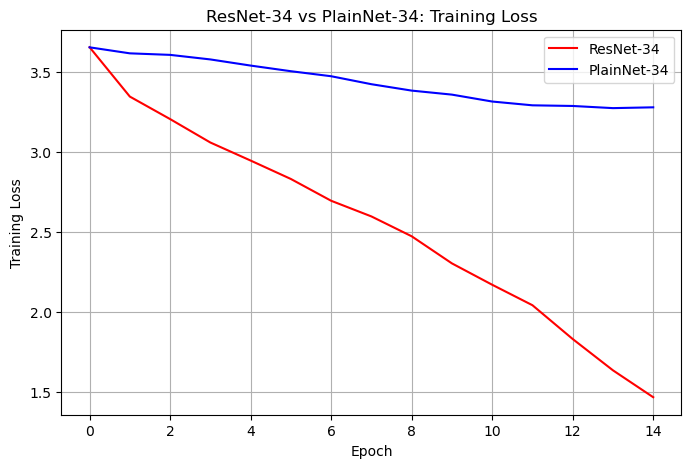

<Figure size 640x480 with 0 Axes>

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(resnet34_train_losses, 'r', label='ResNet-34')
plt.plot(plain34_train_losses, 'b', label='PlainNet-34')

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('ResNet-34 vs PlainNet-34: Training Loss')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("34_comparison_loss.png")

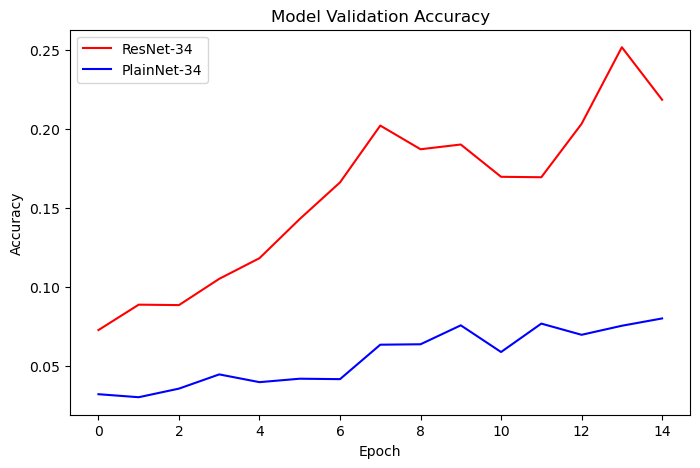

<Figure size 640x480 with 0 Axes>

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(resnet34_val_accuracy, 'r', label='ResNet-34')
plt.plot(plain34_val_accuracy, 'b', label='PlainNet-34')

plt.title('Model Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()
plt.savefig("34_comparison_val.png")

## 3-5 ResNet-50 Training

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model
num_classes = len(train_dataset.classes)
model = build_resnet('50', num_classes=num_classes).to(device)

# Loss / Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

# Train
num_epochs = 15

resnet50_train_losses = []
resnet50_val_accuracy = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_loss / train_total
    train_acc = train_correct / train_total
    resnet50_train_losses.append(train_loss)

    model.eval()
    test_loss_sum = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss_sum += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    test_loss = test_loss_sum / test_total
    test_acc = test_correct / test_total
    resnet50_val_accuracy.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch [1/15] Train Loss: 3.7462, Train Acc: 0.0516 | Test Loss: 3.9027, Test Acc: 0.0463
Epoch [2/15] Train Loss: 3.4992, Train Acc: 0.0720 | Test Loss: 3.5416, Test Acc: 0.0782
Epoch [3/15] Train Loss: 3.2925, Train Acc: 0.1062 | Test Loss: 5.2741, Test Acc: 0.0692
Epoch [4/15] Train Loss: 3.1589, Train Acc: 0.1280 | Test Loss: 3.3503, Test Acc: 0.1115
Epoch [5/15] Train Loss: 3.0058, Train Acc: 0.1620 | Test Loss: 3.0090, Test Acc: 0.1532
Epoch [6/15] Train Loss: 2.8711, Train Acc: 0.1883 | Test Loss: 3.2231, Test Acc: 0.1382
Epoch [7/15] Train Loss: 2.7567, Train Acc: 0.2117 | Test Loss: 3.0665, Test Acc: 0.1624
Epoch [8/15] Train Loss: 2.6302, Train Acc: 0.2508 | Test Loss: 3.6974, Test Acc: 0.1684
Epoch [9/15] Train Loss: 2.5110, Train Acc: 0.2728 | Test Loss: 3.4469, Test Acc: 0.1286
Epoch [10/15] Train Loss: 2.3638, Train Acc: 0.3095 | Test Loss: 4.2635, Test Acc: 0.1063
Epoch [11/15] Train Loss: 2.2600, Train Acc: 0.3399 | Test Loss: 3.8544, Test Acc: 0.1314
Epoch [12/15] Train

In [17]:
resnet50_model = model
torch.save(resnet50_model.state_dict(),"resnet50.pth")

## 3-6 PlainNet-50 Training

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model
num_classes = len(train_dataset.classes)
model = build_plainnet('50', num_classes=num_classes).to(device)

# Loss / Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

# Train
num_epochs = 15

plain50_train_losses = []
plain50_val_accuracy = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_loss / train_total
    train_acc = train_correct / train_total
    plain50_train_losses.append(train_loss)

    model.eval()
    test_loss_sum = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss_sum += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    test_loss = test_loss_sum / test_total
    test_acc = test_correct / test_total
    plain50_val_accuracy.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch [1/15] Train Loss: 3.6715, Train Acc: 0.0293 | Test Loss: 3.6335, Test Acc: 0.0354
Epoch [2/15] Train Loss: 3.5765, Train Acc: 0.0459 | Test Loss: 3.5628, Test Acc: 0.0540
Epoch [3/15] Train Loss: 3.5424, Train Acc: 0.0492 | Test Loss: 3.5451, Test Acc: 0.0458
Epoch [4/15] Train Loss: 3.5287, Train Acc: 0.0478 | Test Loss: 3.5885, Test Acc: 0.0316
Epoch [5/15] Train Loss: 3.5092, Train Acc: 0.0527 | Test Loss: 3.5254, Test Acc: 0.0482
Epoch [6/15] Train Loss: 3.5246, Train Acc: 0.0530 | Test Loss: 3.5324, Test Acc: 0.0510
Epoch [7/15] Train Loss: 3.5095, Train Acc: 0.0533 | Test Loss: 3.5494, Test Acc: 0.0420
Epoch [8/15] Train Loss: 3.4893, Train Acc: 0.0554 | Test Loss: 3.6151, Test Acc: 0.0537
Epoch [9/15] Train Loss: 3.4833, Train Acc: 0.0592 | Test Loss: 3.5615, Test Acc: 0.0499
Epoch [10/15] Train Loss: 3.4639, Train Acc: 0.0590 | Test Loss: 3.4660, Test Acc: 0.0608
Epoch [11/15] Train Loss: 3.4537, Train Acc: 0.0617 | Test Loss: 3.4653, Test Acc: 0.0575
Epoch [12/15] Train

In [19]:
plainnet50_model = model
torch.save(plainnet50_model.state_dict(),"plainnet50.pth")

## 3-7 ReesNet-50 vs PlainNet-50

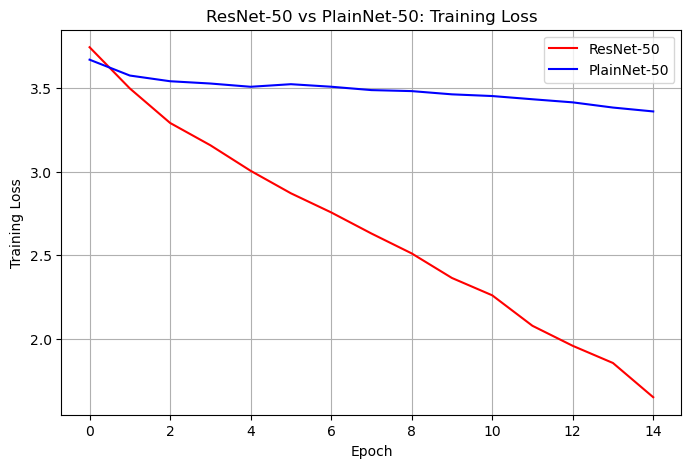

<Figure size 640x480 with 0 Axes>

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(resnet50_train_losses, 'r', label='ResNet-50')
plt.plot(plain50_train_losses, 'b', label='PlainNet-50')

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('ResNet-50 vs PlainNet-50: Training Loss')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("50_comparison_loss.png")

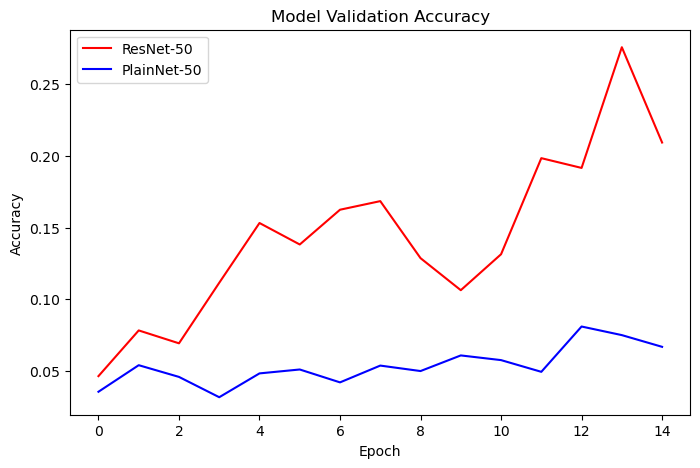

<Figure size 640x480 with 0 Axes>

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(resnet50_val_accuracy, 'r', label='ResNet-50')
plt.plot(plain50_val_accuracy, 'b', label='PlainNet-50')

plt.title('Model Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()
plt.savefig("50_comparison_val.png")

# 4. 오늘의 회고  
오늘은 VGG-16, VGG-19 모델과 ResNet-34, Resnet-50 모델을 직접 구현해서, 학습까지 시켜보았다.  
노드에서 연습삼아 VGG-16과 19를 구현하고, Ablation study까지 해보아서 ResNet을 직접 구현하는 데에 큰 도움이 되었다.  
프로젝트를 진행하는 도중에 처음으로 과적합 사례가 나와서 뭔가 반가웠다(?).  
동시에 다양한 방법을 통해 과적합을 일부분 해결하면서 나름 뿌듯함도 느꼈다.  
또한, 프로젝트를 진행하면서 34, 50 모두에서 ResNet이 우위를 점하는 것을 보고,  
왜 residual training이 중요한지 결과를 보고 깨달았다.  
결과값으로 나온 그래프를 첨부하며 이만 줄이겠다.  

![34_loss](else/3434_loss.png)
![34_val](else/3434_val.png)  
![50_loss](else/5050_loss.png)
![50_val](else/5050_val.png)
